# ML - ARBOL DE DECISION (MODELO)

In [1]:
import numpy as np
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from utils1 import get_classifier_metrics
from sklearn.model_selection import GridSearchCV

## Paso 1. Lectura del conjunto de datos procesado

In [2]:
# Cargamos los dataframes 
with open('../data/processed/04_df_invalids_removed.pkl', 'rb') as f:
    df_invalids_removed = pickle.load(f)

with open('../data/processed/04_df_invalids_mode.pkl', 'rb') as f:
    df_invalids_mode = pickle.load(f)

with open('../data/processed/04_df_invalids_knn.pkl', 'rb') as f:
    df_invalids_knn = pickle.load(f)

## Paso 2. Split

In [3]:
X_invalids_removed = df_invalids_removed.drop('Outcome', axis= 1)
y_invalids_removed = df_invalids_removed['Outcome']

X_invalids_mode= df_invalids_mode.drop('Outcome', axis= 1)
y_invalids_mode = df_invalids_mode['Outcome']

X_invalids_knn= df_invalids_knn.drop('Outcome', axis= 1)
y_invalids_knn = df_invalids_knn['Outcome']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_invalids_removed, y_invalids_removed, test_size=0.2, random_state=21)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_invalids_mode, y_invalids_mode, test_size=0.2, random_state=21)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_invalids_knn, y_invalids_knn, test_size=0.2, random_state=21)

## Paso 3. Análisis y Visualización

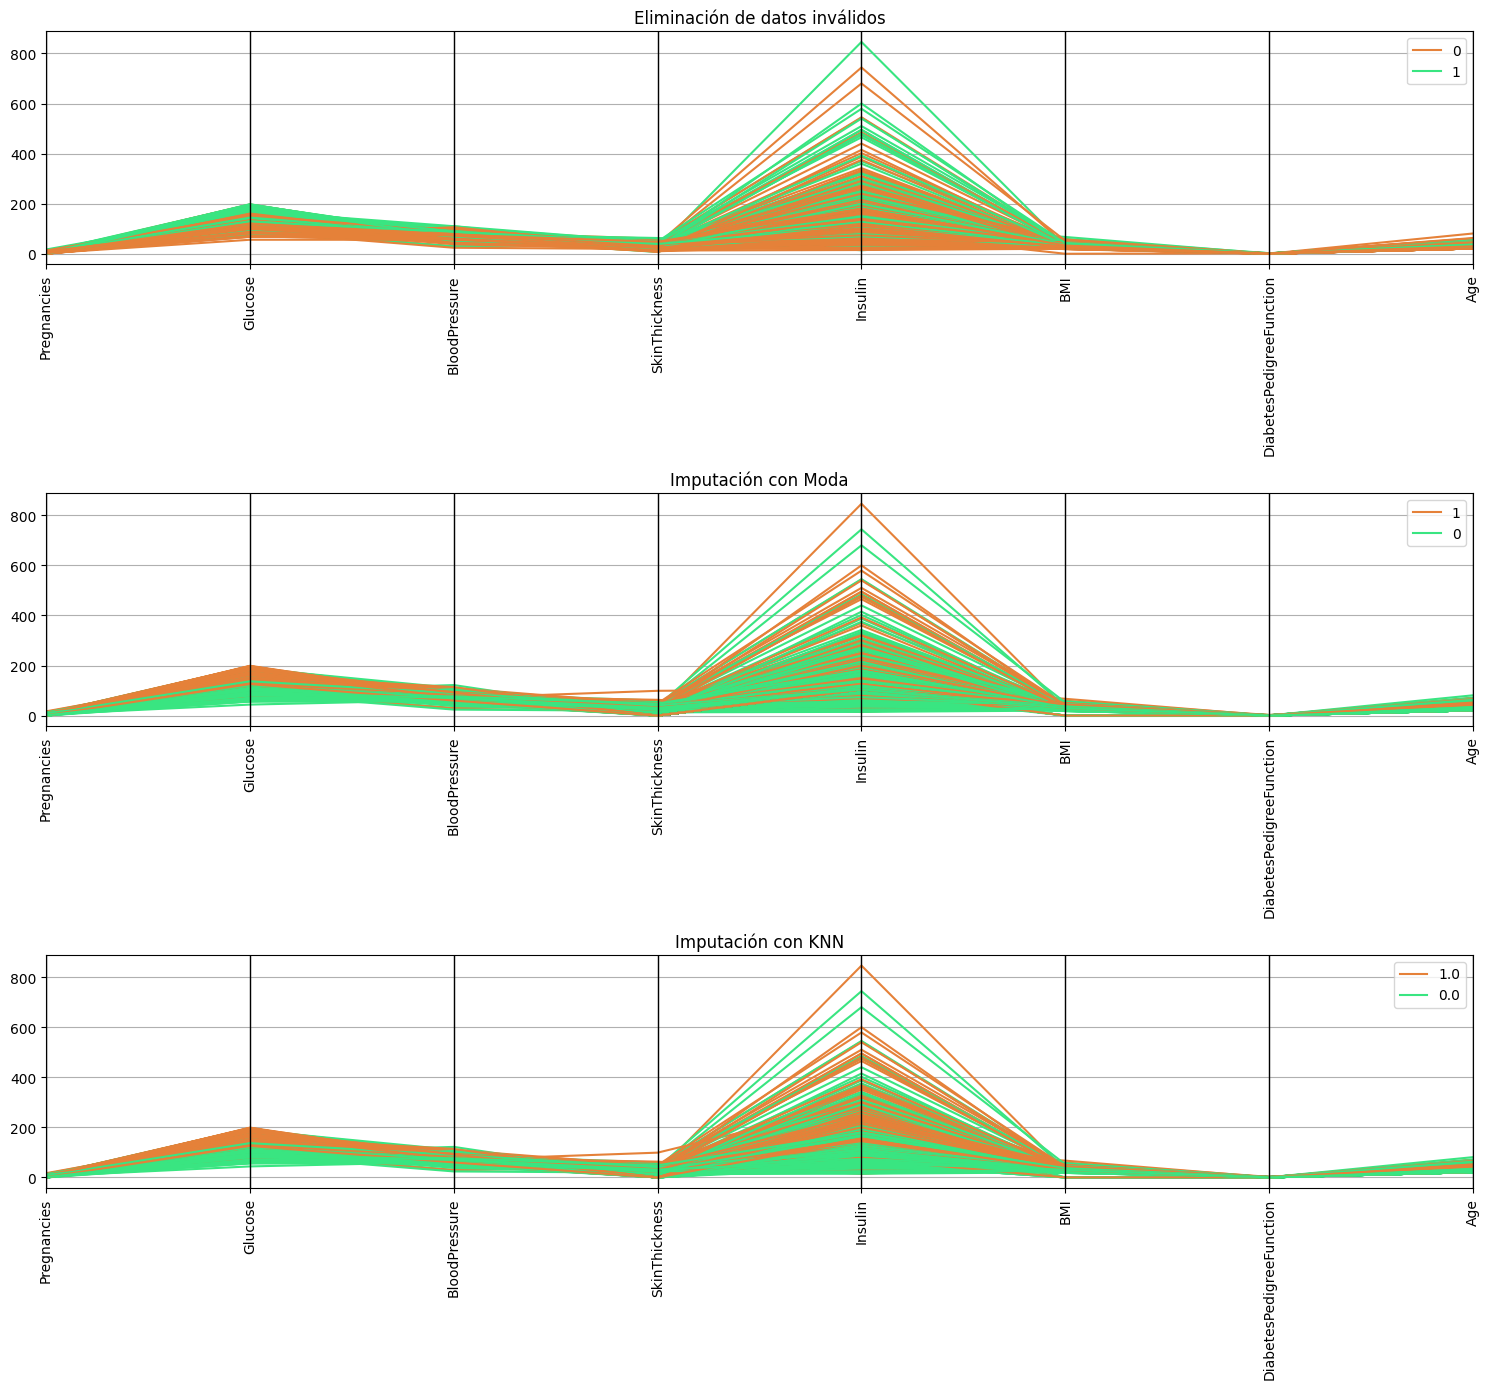

In [4]:
df_1 = X_invalids_removed
df_1['Name'] = y_invalids_removed

df_2 = X_invalids_mode
df_2['Name'] = y_invalids_mode

df_3 = X_invalids_knn
df_3['Name'] = y_invalids_knn

fig, axes = plt.subplots(3, 1, figsize=(15, 14))

pd.plotting.parallel_coordinates(df_1, "Name", color=("#E58139", "#39E581", "#8139E5"), ax=axes[0])
axes[0].set_title('Eliminación de datos inválidos')
axes[0].tick_params(axis='x', rotation=90)

pd.plotting.parallel_coordinates(df_2, "Name", color=("#E58139", "#39E581", "#8139E5"), ax=axes[1])
axes[1].set_title('Imputación con Moda')
axes[1].tick_params(axis='x', rotation=90)

pd.plotting.parallel_coordinates(df_3, "Name", color=("#E58139", "#39E581", "#8139E5"), ax=axes[2])
axes[2].set_title('Imputación con KNN')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()

## Paso 4. Modelado y Ajuste

### Modelos base con los parámetros por defecto (criterio 'gini')

In [5]:
dt_clas_model_1 = DecisionTreeClassifier(random_state=21)
dt_clas_model_2 = DecisionTreeClassifier(random_state=21)
dt_clas_model_3 = DecisionTreeClassifier(random_state=21)

dt_clas_model_1.fit(X_train_1, y_train_1)
dt_clas_model_2.fit(X_train_2, y_train_2)
dt_clas_model_3.fit(X_train_3, y_train_3)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,21
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.6901483050847458, 0.9583333333333334, 'Glucose <= 157.5\ngini = 0.439\nsamples = 314\nvalue = [212, 102]\nclass = Pregnancies'),
 Text(0.5074152542372882, 0.875, 'Age <= 30.5\ngini = 0.354\nsamples = 265\nvalue = [204, 61]\nclass = Pregnancies'),
 Text(0.598781779661017, 0.9166666666666667, 'True  '),
 Text(0.3877118644067797, 0.7916666666666666, 'BMI <= 45.45\ngini = 0.214\nsamples = 172\nvalue = [151, 21]\nclass = Pregnancies'),
 Text(0.3008474576271186, 0.7083333333333334, 'Glucose <= 137.5\ngini = 0.192\nsamples = 167\nvalue = [149, 18]\nclass = Pregnancies'),
 Text(0.17796610169491525, 0.625, 'DiabetesPedigreeFunction <= 0.67\ngini = 0.141\nsamples = 144\nvalue = [133, 11]\nclass = Pregnancies'),
 Text(0.05084745762711865, 0.5416666666666666, 'BMI <= 30.95\ngini = 0.067\nsamples = 115\nvalue = [111, 4]\nclass = Pregnancies'),
 Text(0.03389830508474576, 0.4583333333333333, 'gini = 0.0\nsamples = 56\nvalue = [56, 0]\nclass = Pregnancies'),
 Text(0.06779661016949153, 0.458333

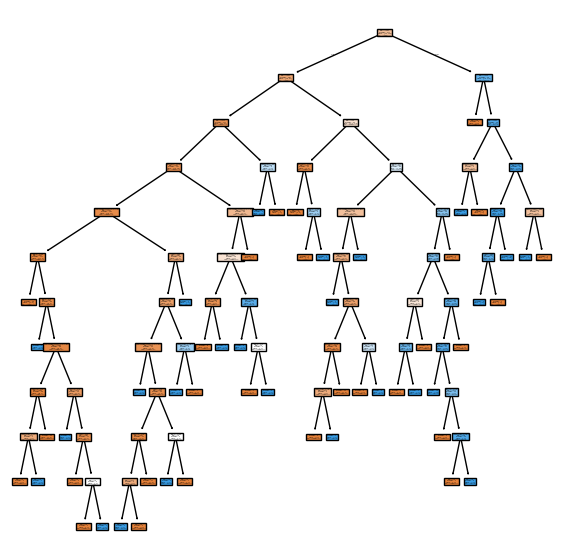

In [6]:
# Visualizamos el arbol
plt.figure(figsize=(7, 7))

tree.plot_tree(dt_clas_model_1,
               feature_names=list(X_train_1.columns),
               class_names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
               filled=True)

[Text(0.6326412671232877, 0.9705882352941176, 'Glucose <= 154.5\ngini = 0.448\nsamples = 614\nvalue = [406, 208]\nclass = Pregnancies'),
 Text(0.41185787671232876, 0.9117647058823529, 'Age <= 30.5\ngini = 0.368\nsamples = 511\nvalue = [387, 124]\nclass = Pregnancies'),
 Text(0.5222495719178082, 0.9411764705882353, 'True  '),
 Text(0.2705479452054795, 0.8529411764705882, 'BMI <= 45.4\ngini = 0.237\nsamples = 305\nvalue = [263, 42]\nclass = Pregnancies'),
 Text(0.18493150684931506, 0.7941176470588235, 'Glucose <= 116.5\ngini = 0.213\nsamples = 297\nvalue = [261, 36]\nclass = Pregnancies'),
 Text(0.0958904109589041, 0.7352941176470589, 'Pregnancies <= 8.5\ngini = 0.098\nsamples = 193\nvalue = [183, 10]\nclass = Pregnancies'),
 Text(0.06027397260273973, 0.6764705882352942, 'DiabetesPedigreeFunction <= 0.666\ngini = 0.09\nsamples = 191\nvalue = [182, 9]\nclass = Pregnancies'),
 Text(0.021917808219178082, 0.6176470588235294, 'BMI <= 30.95\ngini = 0.058\nsamples = 168\nvalue = [163, 5]\nclass

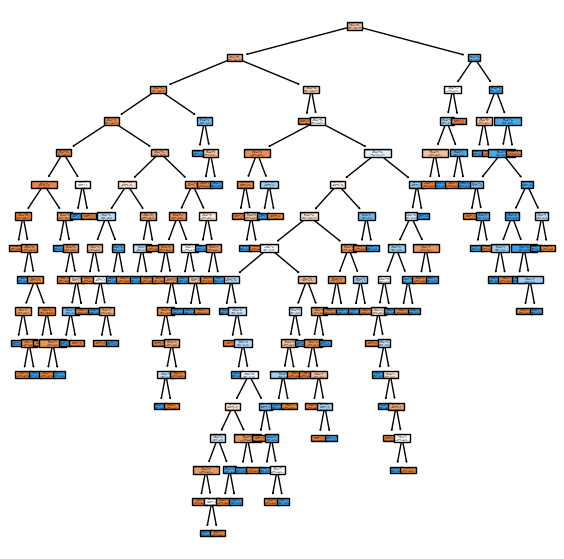

In [7]:
plt.figure(figsize=(7, 7))

tree.plot_tree(dt_clas_model_2,
               feature_names=list(X_train_2.columns),
               class_names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
               filled=True)

[Text(0.5880170863309353, 0.9642857142857143, 'Glucose <= 154.5\ngini = 0.448\nsamples = 614\nvalue = [406, 208]\nclass = Pregnancies'),
 Text(0.3043315347721823, 0.8928571428571429, 'Insulin <= 108.5\ngini = 0.368\nsamples = 511\nvalue = [387, 124]\nclass = Pregnancies'),
 Text(0.44617431055155876, 0.9285714285714286, 'True  '),
 Text(0.16546762589928057, 0.8214285714285714, 'BMI <= 50.85\ngini = 0.153\nsamples = 203\nvalue = [186, 17]\nclass = Pregnancies'),
 Text(0.15587529976019185, 0.75, 'Age <= 29.5\ngini = 0.146\nsamples = 202\nvalue = [186, 16]\nclass = Pregnancies'),
 Text(0.08633093525179857, 0.6785714285714286, 'DiabetesPedigreeFunction <= 0.677\ngini = 0.079\nsamples = 145\nvalue = [139, 6]\nclass = Pregnancies'),
 Text(0.047961630695443645, 0.6071428571428571, 'Pregnancies <= 0.5\ngini = 0.046\nsamples = 127\nvalue = [124, 3]\nclass = Pregnancies'),
 Text(0.02877697841726619, 0.5357142857142857, 'BloodPressure <= 84.5\ngini = 0.18\nsamples = 20\nvalue = [18, 2]\nclass = Pr

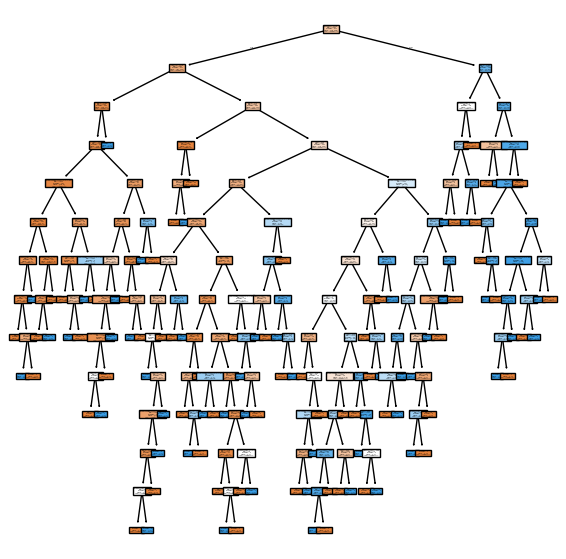

In [8]:
plt.figure(figsize=(7, 7))

tree.plot_tree(dt_clas_model_3,
               feature_names=list(X_train_3.columns),
               class_names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
               filled=True)

## Paso 5. Predicción

In [9]:
y_pred_test_1 = dt_clas_model_1.predict(X_test_1)
y_pred_train_1 = dt_clas_model_1.predict(X_train_1)

y_pred_test_2 = dt_clas_model_2.predict(X_test_2)
y_pred_train_2 = dt_clas_model_2.predict(X_train_2)

y_pred_test_3 = dt_clas_model_3.predict(X_test_3)
y_pred_train_3 = dt_clas_model_3.predict(X_train_3)

In [10]:
get_classifier_metrics(y_pred_test_1, y_test_1, y_pred_train_1, y_train_1, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.696203,0.686414,0.685119,0.696203


In [11]:
get_classifier_metrics(y_pred_test_2, y_test_2, y_pred_train_2, y_train_2, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.681818,0.676187,0.675354,0.681818


In [12]:
get_classifier_metrics(y_pred_test_3, y_test_3, y_pred_train_3, y_train_3, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.668831,0.661274,0.660765,0.668831


> ## Conclusiones:
>
> - Tenemos Overfitting en los tres modelos y los resultados son similares

### Modelos con el hiperparámetro criterio `entropy`

In [13]:
dt_clas_model_1_entropy = DecisionTreeClassifier(random_state=21, criterion='entropy')
dt_clas_model_2_entropy = DecisionTreeClassifier(random_state=21, criterion='entropy')
dt_clas_model_3_entropy = DecisionTreeClassifier(random_state=21, criterion='entropy')

dt_clas_model_1_entropy.fit(X_train_1, y_train_1)
dt_clas_model_2_entropy.fit(X_train_2, y_train_2)
dt_clas_model_3_entropy.fit(X_train_3, y_train_3)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,21
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5828125, 0.9722222222222222, 'Glucose <= 127.5\nentropy = 0.91\nsamples = 314\nvalue = [212, 102]\nclass = Pregnancies'),
 Text(0.328125, 0.9166666666666666, 'Insulin <= 155.5\nentropy = 0.614\nsamples = 191\nvalue = [162, 29]\nclass = Pregnancies'),
 Text(0.45546875, 0.9444444444444444, 'True  '),
 Text(0.18125, 0.8611111111111112, 'DiabetesPedigreeFunction <= 0.495\nentropy = 0.425\nsamples = 150\nvalue = [137, 13]\nclass = Pregnancies'),
 Text(0.1, 0.8055555555555556, 'Insulin <= 143.5\nentropy = 0.211\nsamples = 90\nvalue = [87, 3]\nclass = Pregnancies'),
 Text(0.075, 0.75, 'DiabetesPedigreeFunction <= 0.248\nentropy = 0.155\nsamples = 89\nvalue = [87, 2]\nclass = Pregnancies'),
 Text(0.05, 0.6944444444444444, 'DiabetesPedigreeFunction <= 0.246\nentropy = 0.33\nsamples = 33\nvalue = [31, 2]\nclass = Pregnancies'),
 Text(0.025, 0.6388888888888888, 'entropy = 0.0\nsamples = 31\nvalue = [31, 0]\nclass = Pregnancies'),
 Text(0.075, 0.6388888888888888, 'entropy = 0.0\nsamples = 

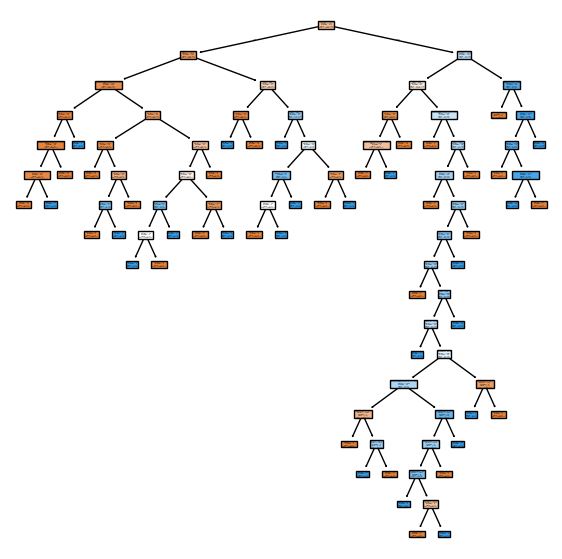

In [14]:
# Visualizamos el arbol
plt.figure(figsize=(7, 7))

tree.plot_tree(dt_clas_model_1_entropy,
               feature_names=list(X_train_1.columns),
               class_names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
               filled=True)

[Text(0.5392984896661367, 0.9761904761904762, 'Glucose <= 154.5\nentropy = 0.924\nsamples = 614\nvalue = [406, 208]\nclass = Pregnancies'),
 Text(0.20896263910969792, 0.9285714285714286, 'BMI <= 26.35\nentropy = 0.799\nsamples = 511\nvalue = [387, 124]\nclass = Pregnancies'),
 Text(0.3741305643879173, 0.9523809523809523, 'True  '),
 Text(0.025437201907790145, 0.8809523809523809, 'Pregnancies <= 2.5\nentropy = 0.166\nsamples = 122\nvalue = [119, 3]\nclass = Pregnancies'),
 Text(0.012718600953895072, 0.8333333333333334, 'entropy = 0.0\nsamples = 69\nvalue = [69, 0]\nclass = Pregnancies'),
 Text(0.03815580286168521, 0.8333333333333334, 'Insulin <= 48.5\nentropy = 0.314\nsamples = 53\nvalue = [50, 3]\nclass = Pregnancies'),
 Text(0.025437201907790145, 0.7857142857142857, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Glucose'),
 Text(0.05087440381558029, 0.7857142857142857, 'Glucose <= 114.5\nentropy = 0.235\nsamples = 52\nvalue = [50, 2]\nclass = Pregnancies'),
 Text(0.0381558028616

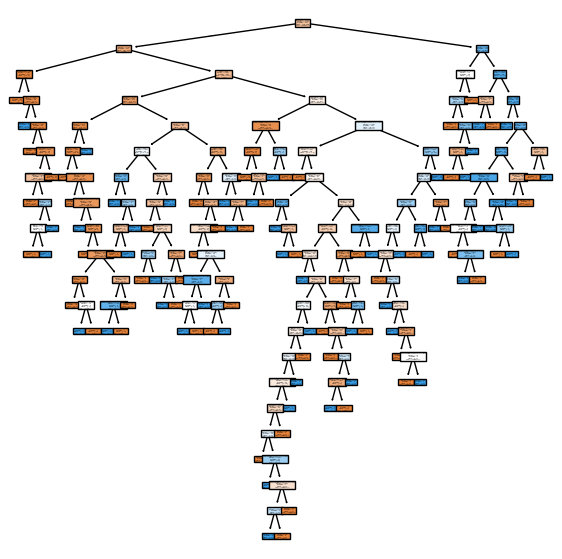

In [15]:
plt.figure(figsize=(7, 7))

tree.plot_tree(dt_clas_model_2_entropy,
               feature_names=list(X_train_2.columns),
               class_names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
               filled=True)

[Text(0.5301675451807228, 0.96875, 'Glucose <= 154.5\nentropy = 0.924\nsamples = 614\nvalue = [406, 208]\nclass = Pregnancies'),
 Text(0.19135918674698796, 0.90625, 'BMI <= 26.35\nentropy = 0.799\nsamples = 511\nvalue = [387, 124]\nclass = Pregnancies'),
 Text(0.3607633659638554, 0.9375, 'True  '),
 Text(0.04819277108433735, 0.84375, 'Pregnancies <= 2.5\nentropy = 0.166\nsamples = 122\nvalue = [119, 3]\nclass = Pregnancies'),
 Text(0.03614457831325301, 0.78125, 'entropy = 0.0\nsamples = 69\nvalue = [69, 0]\nclass = Pregnancies'),
 Text(0.060240963855421686, 0.78125, 'Age <= 30.5\nentropy = 0.314\nsamples = 53\nvalue = [50, 3]\nclass = Pregnancies'),
 Text(0.04819277108433735, 0.71875, 'DiabetesPedigreeFunction <= 0.396\nentropy = 0.491\nsamples = 28\nvalue = [25, 3]\nclass = Pregnancies'),
 Text(0.024096385542168676, 0.65625, 'Pregnancies <= 8.5\nentropy = 0.25\nsamples = 24\nvalue = [23, 1]\nclass = Pregnancies'),
 Text(0.012048192771084338, 0.59375, 'entropy = 0.0\nsamples = 23\nvalu

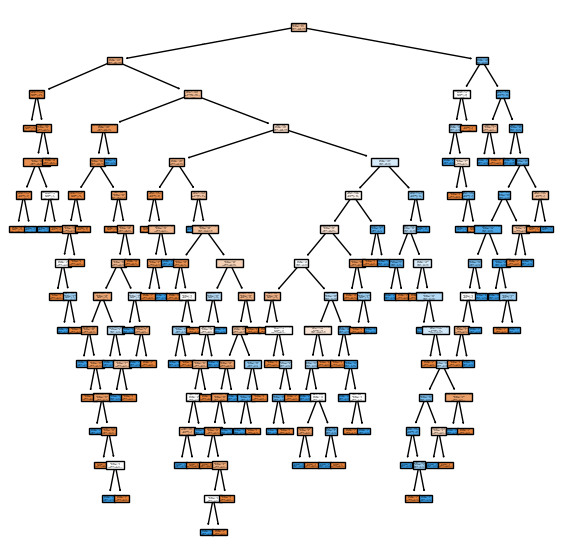

In [16]:
plt.figure(figsize=(7, 7))

tree.plot_tree(dt_clas_model_3_entropy,
               feature_names=list(X_train_3.columns),
               class_names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
               filled=True)

In [17]:
# Predicciones
y_pred_test_1_entropy = dt_clas_model_1_entropy.predict(X_test_1)
y_pred_train_1_entropy = dt_clas_model_1_entropy.predict(X_train_1)

y_pred_test_2_entropy = dt_clas_model_2_entropy.predict(X_test_2)
y_pred_train_2_entropy = dt_clas_model_2_entropy.predict(X_train_2)

y_pred_test_3_entropy = dt_clas_model_3_entropy.predict(X_test_3)
y_pred_train_3_entropy = dt_clas_model_3_entropy.predict(X_train_3)

In [18]:
get_classifier_metrics(y_pred_test_1_entropy, y_test_1, y_pred_train_1_entropy, y_train_1, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.00000,1.0000,1.000000
Test set,0.746835,0.73062,0.7428,0.746835


In [19]:
get_classifier_metrics(y_pred_test_2_entropy, y_test_2, y_pred_train_2_entropy, y_train_2, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.720779,0.719392,0.718563,0.720779


In [20]:
get_classifier_metrics(y_pred_test_3_entropy, y_test_3, y_pred_train_3_entropy, y_train_3, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.00000,1.000000,1.000000,1.00000
Test set,0.62987,0.617107,0.616585,0.62987


> ## Conclusiones:
>
> - Con el algoritmo `entropy` los resultados del modelo 1 y 2 han mejorado, pero seguimos teniendo overfitting

### Modelos con el hiperparámetro criterio `log_loss`

In [21]:
dt_clas_model_1_logloss = DecisionTreeClassifier(random_state=21, criterion='log_loss')
dt_clas_model_2_logloss = DecisionTreeClassifier(random_state=21, criterion='log_loss')
dt_clas_model_3_logloss = DecisionTreeClassifier(random_state=21, criterion='log_loss')

dt_clas_model_1_logloss.fit(X_train_1, y_train_1)
dt_clas_model_2_logloss.fit(X_train_2, y_train_2)
dt_clas_model_3_logloss.fit(X_train_3, y_train_3)

,criterion,'log_loss'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,21
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5828125, 0.9722222222222222, 'Glucose <= 127.5\nlog_loss = 0.91\nsamples = 314\nvalue = [212, 102]\nclass = Pregnancies'),
 Text(0.328125, 0.9166666666666666, 'Insulin <= 155.5\nlog_loss = 0.614\nsamples = 191\nvalue = [162, 29]\nclass = Pregnancies'),
 Text(0.45546875, 0.9444444444444444, 'True  '),
 Text(0.18125, 0.8611111111111112, 'DiabetesPedigreeFunction <= 0.495\nlog_loss = 0.425\nsamples = 150\nvalue = [137, 13]\nclass = Pregnancies'),
 Text(0.1, 0.8055555555555556, 'Insulin <= 143.5\nlog_loss = 0.211\nsamples = 90\nvalue = [87, 3]\nclass = Pregnancies'),
 Text(0.075, 0.75, 'DiabetesPedigreeFunction <= 0.248\nlog_loss = 0.155\nsamples = 89\nvalue = [87, 2]\nclass = Pregnancies'),
 Text(0.05, 0.6944444444444444, 'DiabetesPedigreeFunction <= 0.246\nlog_loss = 0.33\nsamples = 33\nvalue = [31, 2]\nclass = Pregnancies'),
 Text(0.025, 0.6388888888888888, 'log_loss = 0.0\nsamples = 31\nvalue = [31, 0]\nclass = Pregnancies'),
 Text(0.075, 0.6388888888888888, 'log_loss = 0.0\nsa

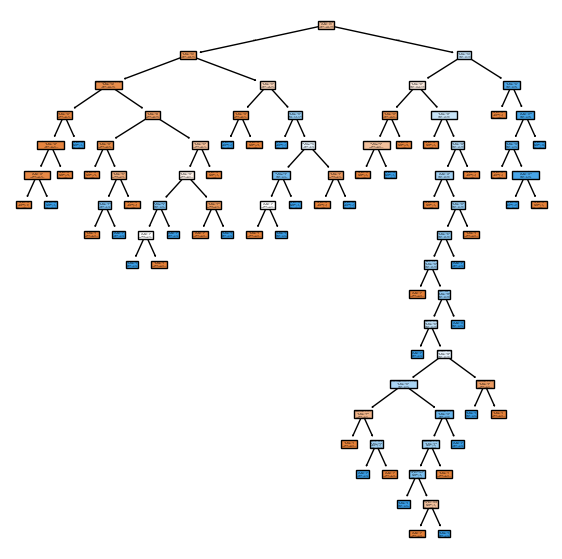

In [22]:
# Visualizamos el arbol
plt.figure(figsize=(7, 7))

tree.plot_tree(dt_clas_model_1_logloss,
               feature_names=list(X_train_1.columns),
               class_names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
               filled=True)

[Text(0.5392984896661367, 0.9761904761904762, 'Glucose <= 154.5\nlog_loss = 0.924\nsamples = 614\nvalue = [406, 208]\nclass = Pregnancies'),
 Text(0.20896263910969792, 0.9285714285714286, 'BMI <= 26.35\nlog_loss = 0.799\nsamples = 511\nvalue = [387, 124]\nclass = Pregnancies'),
 Text(0.3741305643879173, 0.9523809523809523, 'True  '),
 Text(0.025437201907790145, 0.8809523809523809, 'Pregnancies <= 2.5\nlog_loss = 0.166\nsamples = 122\nvalue = [119, 3]\nclass = Pregnancies'),
 Text(0.012718600953895072, 0.8333333333333334, 'log_loss = 0.0\nsamples = 69\nvalue = [69, 0]\nclass = Pregnancies'),
 Text(0.03815580286168521, 0.8333333333333334, 'Insulin <= 48.5\nlog_loss = 0.314\nsamples = 53\nvalue = [50, 3]\nclass = Pregnancies'),
 Text(0.025437201907790145, 0.7857142857142857, 'log_loss = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Glucose'),
 Text(0.05087440381558029, 0.7857142857142857, 'Glucose <= 114.5\nlog_loss = 0.235\nsamples = 52\nvalue = [50, 2]\nclass = Pregnancies'),
 Text(0.038155

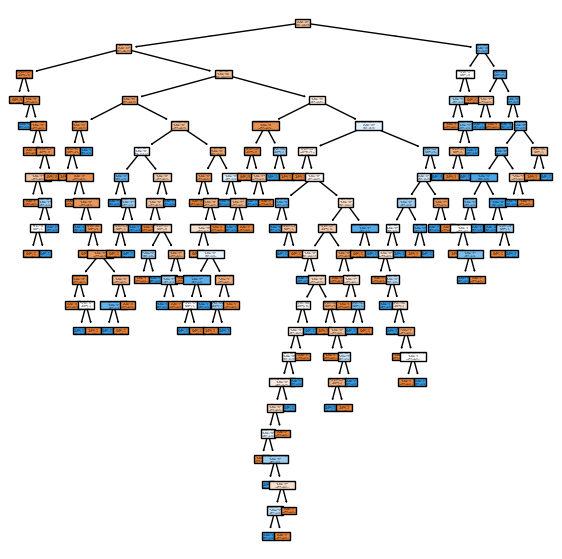

In [23]:
# Visualizamos el arbol
plt.figure(figsize=(7, 7))

tree.plot_tree(dt_clas_model_2_logloss,
               feature_names=list(X_train_2.columns),
               class_names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
               filled=True)

[Text(0.5301675451807228, 0.96875, 'Glucose <= 154.5\nlog_loss = 0.924\nsamples = 614\nvalue = [406, 208]\nclass = Pregnancies'),
 Text(0.19135918674698796, 0.90625, 'BMI <= 26.35\nlog_loss = 0.799\nsamples = 511\nvalue = [387, 124]\nclass = Pregnancies'),
 Text(0.3607633659638554, 0.9375, 'True  '),
 Text(0.04819277108433735, 0.84375, 'Pregnancies <= 2.5\nlog_loss = 0.166\nsamples = 122\nvalue = [119, 3]\nclass = Pregnancies'),
 Text(0.03614457831325301, 0.78125, 'log_loss = 0.0\nsamples = 69\nvalue = [69, 0]\nclass = Pregnancies'),
 Text(0.060240963855421686, 0.78125, 'Age <= 30.5\nlog_loss = 0.314\nsamples = 53\nvalue = [50, 3]\nclass = Pregnancies'),
 Text(0.04819277108433735, 0.71875, 'DiabetesPedigreeFunction <= 0.396\nlog_loss = 0.491\nsamples = 28\nvalue = [25, 3]\nclass = Pregnancies'),
 Text(0.024096385542168676, 0.65625, 'Pregnancies <= 8.5\nlog_loss = 0.25\nsamples = 24\nvalue = [23, 1]\nclass = Pregnancies'),
 Text(0.012048192771084338, 0.59375, 'log_loss = 0.0\nsamples = 

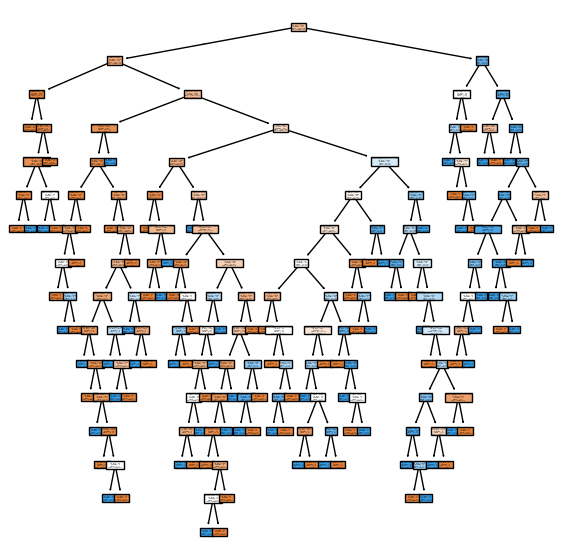

In [24]:
# Visualizamos el arbol
plt.figure(figsize=(7, 7))

tree.plot_tree(dt_clas_model_3_logloss,
               feature_names=list(X_train_3.columns),
               class_names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'],
               filled=True)

In [25]:
y_pred_test_1_logloss = dt_clas_model_1_logloss.predict(X_test_1)
y_pred_train_1_logloss = dt_clas_model_1_logloss.predict(X_train_1)

y_pred_test_2_logloss = dt_clas_model_2_logloss.predict(X_test_2)
y_pred_train_2_logloss = dt_clas_model_2_logloss.predict(X_train_2)

y_pred_test_3_logloss = dt_clas_model_3_logloss.predict(X_test_3)
y_pred_train_3_logloss = dt_clas_model_3_logloss.predict(X_train_3)

In [26]:
get_classifier_metrics(y_pred_test_1_logloss, y_test_1, y_pred_train_1_logloss, y_train_1, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.00000,1.0000,1.000000
Test set,0.746835,0.73062,0.7428,0.746835


In [27]:
get_classifier_metrics(y_pred_test_2_logloss, y_test_2, y_pred_train_2_logloss, y_train_2, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.720779,0.719392,0.718563,0.720779


In [28]:
get_classifier_metrics(y_pred_test_3_logloss, y_test_3, y_pred_train_3_logloss, y_train_3, average="weighted")


,Accuracy,F1 Score,Precision,Recall
Train set,1.00000,1.000000,1.000000,1.00000
Test set,0.62987,0.617107,0.616585,0.62987


> ## Conclusiones:
>
> - Obtenemos los mismos resultados con el algoritmo `log_loss` que con `entropy`
> - Esto puede pasar ya que son algoritmos parecidos y ambos utilizan conceptos relacionados con la entropía pra medir la impureza y guiar divisiones
> - Los modelos que vamos a optimizar van a ser: `dt_clas_model_1_entropy`, `dt_clas_model_2_entropy` y `dt_clas_model_3_entropy`

### Modelos  optimizado con los hiperparámetros de `GridSearchCV`

In [ ]:
# Definimos los parámetros que queremos ajustar a mano

param_grid = {'criterion': ['gini', 'entropy', 'log_loss'],
              'max_depth': [3, 5, 10, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],
              'max_features': [None, 'sqrt', 'log2'],
              'class_weight': [None, 'balanced']}

grid_1 = GridSearchCV(dt_clas_model_1_entropy,
                      param_grid,
                      scoring='recall',
                      cv=5)

grid_2 = GridSearchCV(dt_clas_model_2_entropy,
                      param_grid,
                      scoring='recall',
                      cv=5)

grid_3 = GridSearchCV(dt_clas_model_3_entropy,
                      param_grid,
                      scoring='recall',
                      cv=5)


In [30]:
# Entrenamos el grid con los hiperparametros
grid_1.fit(X_train_1, y_train_1)
#Devuelvemos los mejores parametros despues de entrenarlo
grid_1.best_params_

{'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': None,
 'min_samples_leaf': 2,
 'min_samples_split': 10}

In [31]:
grid_2.fit(X_train_2, y_train_2)
grid_2.best_params_

{'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': None,
 'min_samples_leaf': 2,
 'min_samples_split': 10}

In [32]:
grid_3.fit(X_train_3, y_train_3)
grid_3.best_params_

{'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 5,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'min_samples_split': 2}

In [33]:
#Modelos con los mejores parametros
grid_model_1 = grid_1.best_estimator_
grid_model_2 = grid_2.best_estimator_
grid_model_3 = grid_3.best_estimator_

In [34]:
# Repetimos el entrenamiento pero ahora con el grid que tiene los hiperparametros establecidos
grid_model_1.fit(X_train_1, y_train_1)
grid_model_2.fit(X_train_2, y_train_2)
grid_model_3.fit(X_train_3, y_train_3)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,21
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [35]:
y_pred_test_1_grid = grid_model_1.predict(X_test_1)
y_pred_train_1_grid = grid_model_1.predict(X_train_1)

y_pred_test_2_grid = grid_model_2.predict(X_test_2)
y_pred_train_2_grid = grid_model_2.predict(X_train_2)

y_pred_test_3_grid = grid_model_3.predict(X_test_3)
y_pred_train_3_grid = grid_model_3.predict(X_train_3)

In [36]:
get_classifier_metrics(y_pred_test_1_grid, y_test_1, y_pred_train_1_grid, y_train_1, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,0.859873,0.863375,0.880689,0.859873
Test set,0.670886,0.673269,0.676500,0.670886


In [37]:
get_classifier_metrics(y_pred_test_2_grid, y_test_2, y_pred_train_2_grid, y_train_2, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,0.802932,0.808181,0.848416,0.802932
Test set,0.707792,0.711358,0.728259,0.707792


In [38]:
get_classifier_metrics(y_pred_test_3_grid, y_test_3, y_pred_train_3_grid, y_train_3, average="weighted")

,Accuracy,F1 Score,Precision,Recall
Train set,0.763844,0.769677,0.794581,0.763844
Test set,0.733766,0.734155,0.734605,0.733766


In [40]:
#Guardamos el mejor modelo
with open('../models/04-dt-grid_model_3', 'wb') as f:
    pickle.dump(grid_model_3, f)

> ## Conclusiones:
>
> - Optimizando hiperparámetros con `GridSearchCV` hemos mejorado los resultados del modelo 2 y 3.
> - Llegamos a la conclusion final que el mejor modelo es el 3 (imputando los datos invalidos con `KNNImputer`):
>
>  1. Tiene mejores métricas en el conjunto de test
>  2. Es el modelo que menos overfitting tiene